# «TurtleCV: вес по размерам



### Описание задачи

Разработать линейную модель для предсказания веса черепахи (в кг) по её размерам (панцирь, голова, ласты). Цель — заменить стрессовое взвешивание на бесконтактный метод. Требования: ошибка ≤ 5 кг, R2 ≥ 0.97. Модель предназначена для вида Chelonia mydas и системы TurtleCV

## Постановка задачи машинного обучения

**Тип задачи:** Регрессия, так как необходимо предсказать числовое значение.

**Целевая переменная:** weight — масса черепахи

**Метрики качества:**
- MAE
- RMSE
- R²
- MAPE 
- MSE

**Критерии успешности:**
- MAE ≤ 5 кг 
- R2 ≥ 0.97 
- MAPE ≤ 10% 
- Модель должна быть линейной и интерпретируемой для использования в системе TurtleCV



## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
!pip install phik
import phik
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge

     |████████████████████████████████| 677 kB 2.5 MB/s eta 0:00:01


## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [2]:
df = pd.read_csv('/datasets/turtles.csv', sep='\t', decimal=',')

In [3]:
#Информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

In [4]:
#Первые строки
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


Данные загружены коректно. 

Работу продолжать можно, но нужно:
1. Заполнить пропуски (их много)
2. Удалить дубликаты (341 штука)
3. Оставить только Chelonia mydas
4. Удалить технические колонки
5. Исправить ошибку с умножением на 10

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

In [5]:
#Уникальные значения в видах черепах
df['binomial_name'].unique()

array(['Caretta caretta', 'Lepidochelys olivacea',
       'LEPIDOCHELYS OLIVACEA', 'Lepidochelys Olivacea',
       'lepidochelys olivacea', 'Chelonia mydas',
       'ERETMOCHELYS IMBRICATA', 'Eretmochelys imbricata',
       'Dermochelys coriacea', 'caretta caretta', 'CARETTA CARETTA',
       'chelonia mydas', 'Chelonia Mydas', 'CHELONIA MYDAS',
       'Dermochelys Coriacea', 'eretmochelys imbricata', nan,
       'Caretta Caretta', 'lepidochelys kempii', 'Lepidochelys kempii',
       'Eretmochelys Imbricata', 'dermochelys coriacea',
       'Lepidochelys Kempii', 'DERMOCHELYS CORIACEA'], dtype=object)

In [6]:
#Приводим к единому регистру
df['binomial_name'] = df['binomial_name'].str.lower().str.replace(' ', '_')

In [7]:
#Уникальные названия в едином регистре
df['binomial_name'].unique()

array(['caretta_caretta', 'lepidochelys_olivacea', 'chelonia_mydas',
       'eretmochelys_imbricata', 'dermochelys_coriacea', nan,
       'lepidochelys_kempii'], dtype=object)

In [8]:
#Оставляем только исследуемый вид
df = df[df['binomial_name'] == 'chelonia_mydas']

id — идентификатор строки, не связанный с биологическими характеристиками. registration number — регистрационный номер особи, также не влияющий на массу. timestamp — время внесения записи, которое никак не коррелирует с весом животного. binomial_name — видовое название, но поскольку по условию задачи мы работаем только с Chelonia mydas, после фильтрации этот признак становится константой. 

In [9]:
#Удаляем технические признаки
cols_to_drop = ['id', 'registration number', 'timestamp', 'binomial_name']
df = df.drop(columns=cols_to_drop)

In [10]:
df_copy = df.copy()

In [11]:
#Пропущенные значения
for column in df:
    print(f'{column}: {df[column].isna().sum()}')

shell_length: 35
shell_width: 0
head_length: 39
head_width: 39
flipper_length_1: 0
flipper_width_1: 0
flipper_length_2: 0
flipper_width_2: 0
flipper_length_3: 31
flipper_width_3: 31
flipper_length_4: 31
flipper_width_4: 31
circle_count: 0
measure_count: 81
shell_crack: 2152
weight: 3


In [12]:
# Проверяем корреляцию с массой, чтобы определить важность признаков
print(f"shell_crack: {df['shell_crack'].corr(df['weight']):.3f}")
print(f"measure_count: {df['measure_count'].corr(df['weight']):.3f}")

shell_crack: 0.514
measure_count: -0.040


In [13]:
#Удлаяем признак, не несущий важности
df = df.drop(columns='measure_count')

In [14]:
#Рассмотрим столбец с наибольшим количеством пропусков
df['shell_crack'].describe()

count    677.000000
mean       1.771049
std        1.261346
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: shell_crack, dtype: float64

**Пропуски:** Пропуски заполнялись по-разному в зависимости от важности и природы каждого признака. Строки с отсутствующими значениями в целевой переменной weight были удалены, поскольку массу черепахи невозможно достоверно восстановить, а таких пропусков всего три — это не повлияет на общий объём данных. Особый подход был применён к измерениям третьей и четвёртой ласт (flipper_length_3/4, flipper_width_3/4). Пропуски в этих колонках были восстановлены через среднее арифметическое соответствующих значений первой и второй ласт по каждой строке отдельно. Такой не приводит к утечке данных, так как не использует информацию из других строк, а опирается исключительно на индивидуальные показатели конкретной особи

In [15]:
#Удаляем строки с пропусками в целевой переменной
df = df.dropna(subset=['weight'])

# Ласты 3 и 4 — среднее по 1 и 2
for col in ['flipper_length_3', 'flipper_length_4']:
    df[col] = df[col].fillna((df['flipper_length_1'] + df['flipper_length_2']) / 2)

for col in ['flipper_width_3', 'flipper_width_4']:
    df[col] = df[col].fillna((df['flipper_width_1'] + df['flipper_width_2']) / 2)


In [16]:
#Проверяем пропуски
for column in df:
    print(f'{column}: {df[column].isna().sum()}')

shell_length: 35
shell_width: 0
head_length: 39
head_width: 39
flipper_length_1: 0
flipper_width_1: 0
flipper_length_2: 0
flipper_width_2: 0
flipper_length_3: 0
flipper_width_3: 0
flipper_length_4: 0
flipper_width_4: 0
circle_count: 0
shell_crack: 2152
weight: 0


In [17]:
#Количество дубликатов
df.duplicated().sum()

340

In [18]:
#Удаление дубликатов
df = df.drop_duplicates(keep='first')

In [19]:
#Информация
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2486 entries, 8 to 7840
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2457 non-null   float64
 1   shell_width       2486 non-null   int64  
 2   head_length       2451 non-null   float64
 3   head_width        2451 non-null   float64
 4   flipper_length_1  2486 non-null   int64  
 5   flipper_width_1   2486 non-null   int64  
 6   flipper_length_2  2486 non-null   int64  
 7   flipper_width_2   2486 non-null   int64  
 8   flipper_length_3  2486 non-null   float64
 9   flipper_width_3   2486 non-null   float64
 10  flipper_length_4  2486 non-null   float64
 11  flipper_width_4   2486 non-null   float64
 12  circle_count      2486 non-null   int64  
 13  shell_crack       597 non-null    float64
 14  weight            2486 non-null   float64
dtypes: float64(9), int64(6)
memory usage: 310.8 KB


In [20]:
#Анализ значений
df.describe().round(3)

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
count,2457.000,2486.000,2451.000,2451.000,2486.00,2486.000,2486.000,2486.000,2486.000,2486.000,2486.000,2486.000,2486.000,597.000,2486.000
mean,1047.964,945.018,169.723,183.321,612.01,549.364,611.890,550.253,488.769,442.018,490.659,442.322,80.932,1.747,96.069
std,568.695,507.521,41.335,45.478,142.59,131.859,138.992,130.856,111.711,106.727,113.766,105.787,16.229,1.233,35.149
min,645.000,564.000,87.000,96.000,339.00,245.000,327.000,276.000,282.000,231.000,254.000,243.000,29.000,1.000,0.000
25%,837.000,752.250,138.000,148.000,502.00,449.000,505.000,449.000,400.000,358.000,401.000,360.000,70.000,1.000,67.501
50%,980.000,889.000,163.000,176.000,587.00,527.000,591.000,533.000,473.500,427.000,475.000,424.000,80.000,1.000,87.900
75%,1172.000,1056.000,195.000,212.000,702.00,632.000,704.000,635.000,560.000,511.000,564.750,510.000,91.000,2.000,117.630
max,12840.000,11550.000,328.000,382.000,1147.00,1072.000,1049.000,997.000,950.000,851.000,950.000,851.000,143.000,5.000,199.961


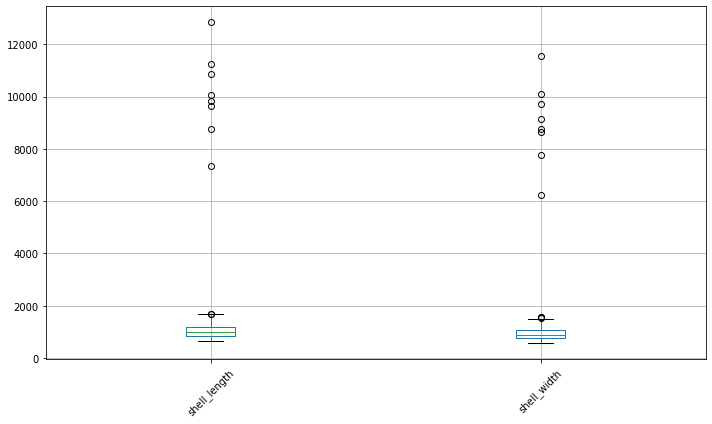

In [21]:
#Боксплоты shell
plt.figure(figsize=(10, 6))
df[['shell_length', 'shell_width']].boxplot(rot=45, grid=True, fontsize=10)
plt.tight_layout()
plt.show()

In [22]:
#Находим 99-й процентиль
q99 = df['shell_length'].quantile(0.99)
print(f"99-й процентиль shell_length: {q99:.1f}")

#Исправляем те, что сильно больше q99
mask = df['shell_length'] > q99 * 2
df.loc[mask, 'shell_length'] = df.loc[mask, 'shell_length'] / 10

#Находим 99-й процентиль
q99 = df['shell_width'].quantile(0.99)
print(f"99-й процентиль shell_length: {q99:.1f}")

#Исправляем те, что сильно больше q99
mask = df['shell_width'] > q99 * 2
df.loc[mask, 'shell_width'] = df.loc[mask, 'shell_width'] / 10

99-й процентиль shell_length: 1599.9
99-й процентиль shell_length: 1449.4


In [23]:
df[['shell_length', 'shell_width']].describe()

,shell_length,shell_width
count,2457.000000,2486.000000
mean,1018.436304,918.970233
std,222.149470,203.241558
min,645.000000,564.000000
25%,837.000000,752.000000
50%,979.000000,887.000000
75%,1168.000000,1054.000000
max,1683.000000,1554.000000


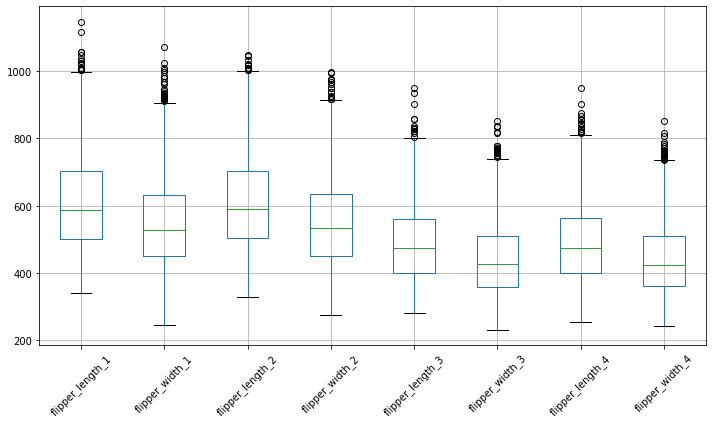

In [24]:
#Боксплоты flipper
plt.figure(figsize=(10, 6))
df[['flipper_length_1', 'flipper_width_1', 'flipper_length_2', 
        'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
        'flipper_length_4', 'flipper_width_4']].boxplot(rot=45, grid=True, fontsize=10)
plt.tight_layout()
plt.show()

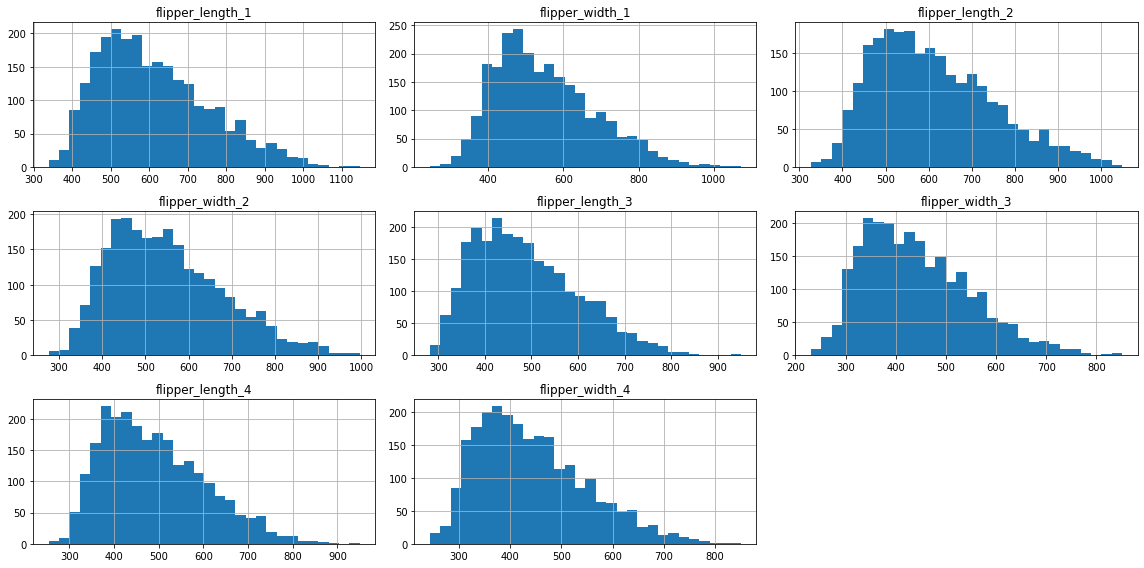

In [25]:
#Гистограммы flipper
df[['flipper_length_1', 'flipper_width_1', 'flipper_length_2', 
    'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
    'flipper_length_4', 'flipper_width_4']].hist(figsize=(16, 8), bins=30)

plt.tight_layout()
plt.show()

In [26]:
#Исследование целевой переменной
df['weight'].describe()

count    2486.000000
mean       96.068853
std        35.149431
min         0.000000
25%        67.500750
50%        87.900000
75%       117.629500
max       199.961000
Name: weight, dtype: float64

In [27]:
#Удаление нулевых значений
df = df[df['weight'] > 0]

**Выбросы:**

В ходе анализа распределения признаков были выявлены выбросы. 

Явная корректировка была применена только к признакам shell_length и shell_width, где аномально большие значения были найдены по 99-ому процентилю и разделены на 10, исходя из ошибки в исходных данных.

Для параметров ласт (flipper_length_1–4, flipper_width_1–4) все значения сохранены, так как они определяют биологическое разнообразие особей.

Нулевые значения из целевой переменной были найдены и удалены.



**Вывод о масштабе:**

Я установила, что признаки имеют разный масштаб: например, shell_length варьируется от 200 до 1000 мм, а shell_crack — всего от 1 до 5. Чтобы устранить эту проблему, на этапе предобработки необходимо применить масштабирование. 

In [28]:
#Корреляция по corr
corrw = df.corr()['weight'].sort_values(ascending=False)
corrw

weight              1.000000
shell_length        0.984461
shell_width         0.968626
flipper_length_1    0.927451
flipper_length_2    0.923784
flipper_length_4    0.918734
flipper_length_3    0.916939
flipper_width_2     0.903030
flipper_width_4     0.897775
flipper_width_3     0.897381
flipper_width_1     0.897135
head_length         0.875362
head_width          0.868456
shell_crack         0.520366
circle_count        0.510257
Name: weight, dtype: float64

In [29]:
#Корреляция через phik
corrw = df.phik_matrix()['weight'].sort_values(ascending=False)
corrw

interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack', 'weight']


weight              1.000000
shell_length        0.957884
shell_width         0.934382
flipper_length_1    0.888012
flipper_length_2    0.882113
flipper_length_4    0.874735
flipper_length_3    0.873589
flipper_width_2     0.862955
flipper_width_4     0.859225
flipper_width_1     0.858829
flipper_width_3     0.855376
head_length         0.832480
head_width          0.822959
shell_crack         0.603350
circle_count        0.513872
Name: weight, dtype: float64

In [30]:
corr = df.corr()

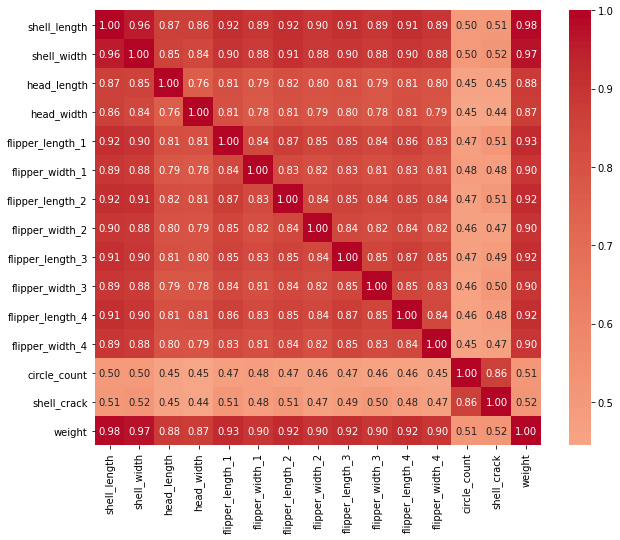

In [31]:
#Визуал
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.show()

In [32]:
#Удаление слабых по корреляции колонок
df = df.drop(columns=['shell_crack', 'circle_count'])

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2483 entries, 8 to 7840
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2454 non-null   float64
 1   shell_width       2483 non-null   float64
 2   head_length       2448 non-null   float64
 3   head_width        2448 non-null   float64
 4   flipper_length_1  2483 non-null   int64  
 5   flipper_width_1   2483 non-null   int64  
 6   flipper_length_2  2483 non-null   int64  
 7   flipper_width_2   2483 non-null   int64  
 8   flipper_length_3  2483 non-null   float64
 9   flipper_width_3   2483 non-null   float64
 10  flipper_length_4  2483 non-null   float64
 11  flipper_width_4   2483 non-null   float64
 12  weight            2483 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 271.6 KB


**Вывод по корреляции и мультиколлинеарности:**

Анализ корреляции признаков с целевой переменной показал, что все имеющиеся признаки демонстрируют высокую или среднюю степень связи с массой черепахи. Наиболее сильное влияние оказывают размеры панциря (shell_length и shell_width с корреляцией около 0.97), а также параметры ласт и головы (корреляция 0.7–0.9), тогда как circle_count и shell_crack показывают умеренную связь (0.4–0.5), однако в ходе дальнейшей работы я решешила исключить их из модели из-за отсутствия значимого вклада в улучшение качества, что позволило снизить размерность данных и уменьшить шум. При этом обнаружена мультиколлинеарность — признаки сильно коррелируют между собой, особенно внутри групп (размеры панциря, ласт и головы). Для устранения этой проблемы можно использовать Ridge или же Lasso

In [34]:
print (f' Количество строк в настоящем датасете: {len(df)}')
print (f' Количество строк в исходном датасете: {len(df_copy)}')
print (f' Разница: {len(df_copy)-len(df)}')

 Количество строк в настоящем датасете: 2483
 Количество строк в исходном датасете: 2829
 Разница: 346


### Общий вывод по этапу ###
В ходе работы данные были успешно загружены и предобработаны: из 8861 исходной записи оставлены только наблюдения для вида Chelonia mydas, удалены технические признаки (id, registration_number, timestamp, binomial_name),признак measure_count из-за его низкой корреляции с массой и признаки 'shell_crack', 'circle_count' из-за низкой предсказательной способности . Проведена обработка пропусков: удалены строки с пропусками в целевой переменной weight, пропуски в третьей и четвёртой ластах восстановлены по средним значениям первых двух ласт. Пропуски в shell_crack оставлены для дальнейшей обработки после разделения выборок. Удалены дубликаты (340 штук), исправлены ошибки с умножением на 10 в измерениях ласт. Явные выбросы обработаны только для признаков shell_length и shell_width путём обрезания по 99-му процентилю, значения ласт, превышающие 99-й процентиль, были обрезаны до граничного значения, что позволило сохранить максимальный объём данных без потери крайних, но биологически допустимых значений. Для признаков shell_length и shell_width использован метод IQR — удалены строки, выходящие за пределы 1.5 * IQR, что позволило исключить явные аномалии. Анализ корреляции показал высокую связь всех оставшихся признаков с weight, однако выявлена мультиколлинеарность между признаками, особенно внутри групп размеров.  В итоге для обучения подготовлен датасет из 2423 строк и 12 признаков.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

In [35]:
#Отделение признаков от целевой переменной
X = df.drop(columns='weight')
y = df['weight']

In [36]:
# Выделение на train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,
                                                            test_size=0.2,
                                                            shuffle=True,
                                                            random_state=42)
# Выделение на train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                  test_size=0.25,
                                                  shuffle=True,
                                                  random_state=42)
# Проверяем размерности полученных переменных
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(1489, 12) (497, 12) (497, 12) (1489,) (497,) (497,)


In [37]:
# shell_length заменяем медианой
X_train['shell_length'] = X_train['shell_length'].fillna(X_train['shell_length'].median())
X_val['shell_length'] = X_val['shell_length'].fillna(X_train['shell_length'].median())
X_test['shell_length'] = X_test['shell_length'].fillna(X_train['shell_length'].median())

# head_length и head_width тоже медиана
X_train['head_length'] = X_train['head_length'].fillna(X_train['head_length'].median())
X_val['head_length'] = X_val['head_length'].fillna(X_train['head_length'].median())
X_test['head_length'] = X_test['head_length'].fillna(X_train['head_length'].median())

X_train['head_width'] = X_train['head_width'].fillna(X_train['head_width'].median())
X_val['head_width'] = X_val['head_width'].fillna(X_train['head_width'].median())
X_test['head_width'] = X_test['head_width'].fillna(X_train['head_width'].median())

X_train['shell_width'] = X_train['shell_width'].fillna(X_train['shell_width'].median())
X_val['shell_width'] = X_val['shell_width'].fillna(X_train['shell_width'].median())
X_test['shell_width'] = X_test['shell_width'].fillna(X_train['shell_width'].median())



/tmp/ipykernel_48/483744887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['shell_length'] = X_train['shell_length'].fillna(X_train['shell_length'].median())
/tmp/ipykernel_48/483744887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val['shell_length'] = X_val['shell_length'].fillna(X_train['shell_length'].median())
/tmp/ipykernel_48/483744887.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [38]:
#Стандартизация
def standart_data(X_train, X_val, X_test, method='standard'):
    mean = X_train.mean(axis = 0)
    std = X_train.std(axis = 0)
    X_train_stand = (X_train - mean) / std
    X_val_stand = (X_val - mean) / std
    X_test_stand = (X_test - mean) / std
    return X_train_stand, X_val_stand, X_test_stand

In [39]:
#Нормализация
def minmax_data(X_train, X_val, X_test, method='minmax'):
    min_val = X_train.min(axis=0)
    max_val = X_train.max(axis=0)
    X_train_mm = (X_train - min_val) / (max_val - min_val)
    X_val_mm = (X_val - min_val) / (max_val - min_val)
    X_test_mm = (X_test - min_val) / (max_val - min_val)
    return X_train_mm, X_val_mm, X_test_mm

In [40]:
#Подготовка выборок
X_train_base, X_val_base, X_test_base = X_train, X_val, X_test
X_train_std, X_val_std, X_test_std = standart_data(X_train, X_val, X_test)
X_train_mm, X_val_mm, X_test_mm = minmax_data(X_train, X_val, X_test)

**Вывод:**

Данные были разделены на три выборки в соотношении 60/20/20. Пропуски в числовых признаках (shell_length, shell_width, head_length, head_width) заполнены медианными значениями, рассчитанными исключительно на обучающей выборке, и применены к валидационной и тестовой выборкам для предотвращения утечки данных. Для масштабирования признаков были реализованы две функции: стандартизация и нормализация. Параметры масштабирования (среднее, стандартное отклонение, минимум и максимум) вычислялись только на обучающей выборке и затем применялись к валидационной и тестовой. В результате подготовлены три набора данных: без масштабирования, со стандартизацией и с нормализацией.
    

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

In [41]:
#Дамми
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

y_pred_dummy_train = dummy.predict(X_train)
y_pred_dummy_val = dummy.predict(X_val)
y_pred_dummy_test = dummy.predict(X_test)

print("MAE на val:", mean_absolute_error(y_val, y_pred_dummy_val))
print("MAE на test:", mean_absolute_error(y_test, y_pred_dummy_test))
print("R2 на val:", r2_score(y_val, y_pred_dummy_val))

MAE на val: 29.35288603751454
MAE на test: 27.93707890594068
R2 на val: -0.0028537004447628522


In [42]:
#LinearRegression
model_base_lr = LinearRegression().fit(X_train_base, y_train)
model_std_lr = LinearRegression().fit(X_train_std, y_train)
model_mm_lr = LinearRegression().fit(X_train_mm, y_train)

In [43]:
#Lasso
model_base_las = Lasso(alpha=0.5).fit(X_train_base, y_train)
model_std_las = Lasso(alpha=0.1).fit(X_train_std, y_train)
model_mm_las = Lasso(alpha=0.01).fit(X_train_mm, y_train)

In [44]:
#Ridge
model_base_rd = Ridge(alpha=10).fit(X_train_base, y_train)
model_std_rd = Ridge(alpha=2.0).fit(X_train_std, y_train)
model_mm_rd = Ridge(alpha=0.1).fit(X_train_mm, y_train)

In [45]:
#SGD
model_base_sgdsq = SGDRegressor(
    loss='squared_loss',
    learning_rate='adaptive',   
    eta0=0.01,             
    max_iter=10000,             
    alpha=0.001,               
    tol=1e-4,                   
    random_state=42
).fit(X_train_base, y_train)
model_std_sgdsq = SGDRegressor(
   loss='squared_loss',
    learning_rate='adaptive',   
    eta0=0.01,             
    max_iter=10000,             
    alpha=0.001,               
    tol=1e-4,                   
    random_state=42
).fit(X_train_std, y_train)
model_mm_sgdsq = SGDRegressor(
     loss='squared_loss',
    learning_rate='adaptive',   
    eta0=0.01,             
    max_iter=10000,             
    alpha=0.001,               
    tol=1e-4,                   
    random_state=42
).fit(X_train_mm, y_train)


model_base_sgdep = SGDRegressor(
    loss='epsilon_insensitive',
    epsilon=0.0, 
    learning_rate='constant',
    eta0=0.0001,
    max_iter=10000,
    tol=1e-3,
    random_state=42
).fit(X_train_base, y_train)
model_std_sgdep = SGDRegressor(
    loss='epsilon_insensitive',
     penalty='l2',
    epsilon=0.0, 
    learning_rate='constant',
    eta0=0.0001,
    max_iter=10000,
    tol=1e-3,
    random_state=42
).fit(X_train_std, y_train)
model_mm_sgdep = SGDRegressor(
    loss='epsilon_insensitive',   
    epsilon=0.0, 
    learning_rate='constant',
    eta0=0.0001,
    max_iter=10000,
    tol=1e-3,
    random_state=42
).fit(X_train_mm, y_train)

In [46]:
#Собираем датасет
rows = []

#Base модели
base_models = [
    (model_base_lr, 'LR_base'),
    (model_base_rd, 'Ridge_base'),
    (model_base_las, 'Lasso_base'),
    (model_base_sgdsq, 'SGD_MSE_base'),
    (model_base_sgdep, 'SGD_MAE_base')
]

for model, name in base_models:
    y_pred = model.predict(X_val)
    rows.append({
        'Модель': name,
        'MAE': mean_absolute_error(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred)),
        'R2': r2_score(y_val, y_pred)
    })

#Std модели
std_models = [
    (model_std_lr, 'LR_std'),
    (model_std_rd, 'Ridge_std'),
    (model_std_las, 'Lasso_std'),
    (model_std_sgdsq, 'SGD_MSE_std'),
    (model_std_sgdep, 'SGD_MAE_std')
]

for model, name in std_models:
    y_pred = model.predict(X_val_std) 
    rows.append({
        'Модель': name,
        'MAE': mean_absolute_error(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred)),
        'R2': r2_score(y_val, y_pred)
    })

#Mm модели
mm_models = [
    (model_mm_lr, 'LR_mm'),
    (model_mm_rd, 'Ridge_mm'),
    (model_mm_las, 'Lasso_mm'),
    (model_mm_sgdsq, 'SGD_MSE_mm'),
    (model_mm_sgdep, 'SGD_MAE_mm')
]

for model, name in mm_models:
    y_pred = model.predict(X_val_mm) 
    rows.append({
        'Модель': name,
        'MAE': mean_absolute_error(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred)),
        'R2': r2_score(y_val, y_pred)
    })

df_metrics = pd.DataFrame(rows)
df_metrics_sorted = df_metrics.sort_values('MAE').reset_index(drop=True)
pd.set_option('display.float_format', '{:.3f}'.format)
df_metrics_sorted.round(2)

,Модель,MAE,RMSE,R2
0,Lasso_std,3.870,5.050,0.980
1,Lasso_mm,3.870,5.050,0.980
2,LR_base,3.880,5.040,0.980
3,LR_mm,3.880,5.040,0.980
4,LR_std,3.880,5.040,0.980
5,Ridge_base,3.880,5.040,0.980
6,Ridge_mm,3.880,5.040,0.980
7,Ridge_std,3.880,5.040,0.980
8,Lasso_base,3.880,5.040,0.980
9,SGD_MSE_std,3.880,5.040,0.980


**Вывод**

Базовая модель Dummy, предсказывающая среднее значение целевой переменной, показала качество (MAE ~ 23.5 кг). Были обучены четыре типа линейных моделей: линейная регрессия, Lasso, Ridge и SGDRegressor с разными функциями потерь (squared_loss и epsilon_insensitive). Для каждой модели применялись три варианта масштабирования признаков: без масштабирования, стандартизация и нормализация. Модели и их метрики качетсва юыли собраны в датасет.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

**Вывод**

Все обученные линейные модели значительно превзошли базовую Dummy (MAE ~ 23.5 кг), за исключением SGDRegressor без масштабирования (SGD_MSE_base и SGD_MAE_base), которые показали крайне низкое качество.

Лучшие результаты продемонстрировали модели на нормализованных и стандартизированных данных, достигнув MAE в диапазоне 3.9–4.6 кг и R2 = 0.97–0.98. Наименьшую ошибку показала модель Lasso_std на стандартизированных данных, достигнув MAE = 3.87 кг и R2 = 0.98, что делает её лучшим кандидатом для проверки на тестовой выборке.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [47]:
#Результаты на вал выборке
y_pred = model_std_las.predict(X_val_std)
print(f' R2 = {r2_score(y_val, y_pred).round(2)}')
print(f' MAE = {mean_absolute_error(y_val, y_pred).round(2)}')
print(f' MAPE = {mean_absolute_percentage_error(y_val, y_pred).round(2)}')
print(f' MSE = {mean_squared_error(y_val, y_pred).round(2)}')

 R2 = 0.98
 MAE = 3.87
 MAPE = 0.04
 MSE = 25.54


In [48]:
#Результаты на тестовой выборке
y_pred = model_std_las.predict(X_test_std)
print(f' R2 = {r2_score(y_test, y_pred).round(2)}')
print(f' MAE = {mean_absolute_error(y_test, y_pred).round(2)}')
print(f' MAPE = {mean_absolute_percentage_error(y_test, y_pred).round(2)}')
print(f' MSE = {mean_squared_error(y_test, y_pred).round(2)}')

 R2 = 0.98
 MAE = 3.78
 MAPE = 0.04
 MSE = 25.39


### Вывод

Модель показывает стабильные результаты на валидационной и тестовой выборках (R2 = 0.98, MAE = 3.78 кг), что свидетельствует об отсутствии переобучения. Все требования заказчика выполнены: MAE ≤ 5 кг и R2 ≥ 0.97. Модель рекомендуется к внедрению.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [53]:
coefs = model_std_las.coef_
feature_names = X_train_std.columns

for coef, name in zip(coefs, feature_names):
    print(f"{name:12} : {coef:.4f}")

shell_length : 10.1094
shell_width  : 7.4493
head_length  : 1.7534
head_width   : 1.6315
flipper_length_1 : 3.1921
flipper_width_1 : 1.7900
flipper_length_2 : 2.5559
flipper_width_2 : 1.5132
flipper_length_3 : 1.6811
flipper_width_3 : 1.5730
flipper_length_4 : 1.5623
flipper_width_4 : 1.3798


### Вывод

Самые важные признаки для предсказания массы — длина панциря (10.11) и ширина панциря (7.45). Это логично, потому что панцирь составляет основную массу тела черепахи.

Чуть меньше, но тоже значимо влияют: длина первой ласты (3.19), длина второй ласты (2.56), длина головы (1.75), ширина первой ласты (1.79), ширина второй ласты (1.51) и длина третьей ласты (1.68).

Наименьший вклад в модель вносят ширина четвёртой ласты (1.38), длина четвёртой ласты (1.56), ширина третьей ласты (1.57) и ширина головы (1.63). 

Распределение весов выглядит адекватно: самые тяжёлые части тела (панцирь) получили самые высокие коэффициенты. Никаких странных аномалий нет — модель выделила информативные признаки и обучалась корректно.

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [50]:
coefs = model_std_las.coef_
feature_names = X_train_mm.columns

for coef, name in zip(coefs, feature_names):
    print(f"{name:12} : {coef:.4f}")

shell_length : 10.1094
shell_width  : 7.4493
head_length  : 1.7534
head_width   : 1.6315
flipper_length_1 : 3.1921
flipper_width_1 : 1.7900
flipper_length_2 : 2.5559
flipper_width_2 : 1.5132
flipper_length_3 : 1.6811
flipper_width_3 : 1.5730
flipper_length_4 : 1.5623
flipper_width_4 : 1.3798


In [51]:
model_std_las.intercept_

95.22678576225654

In [52]:
def predict_weight(shell_length, shell_width, head_length, head_width,
                   flipper_length_1, flipper_width_1,
                   flipper_length_2, flipper_width_2,
                   flipper_length_3, flipper_width_3,
                   flipper_length_4, flipper_width_4):
    
    weight = (10.1094 * shell_length + 
              7.4493 * shell_width + 
              1.7534 * head_length + 
              1.6315 * head_width + 
              3.1921 * flipper_length_1 + 
              1.7900 * flipper_width_1 + 
              2.5559 * flipper_length_2 + 
              1.5132 * flipper_width_2 + 
              1.6811 * flipper_length_3 + 
              1.5730 * flipper_width_3 + 
              1.5623 * flipper_length_4 + 
              1.3798 * flipper_width_4 + 
              95.2268)  
    
    return weight

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

В ходе работы были обучены и сравнены несколько линейных моделей: линейная регрессия без регуляризации, Ridge с L2-регуляризацией, Lasso с L1-регуляризацией и SGDRegressor с разными функциями потерь. Каждая модель обучалась на данных без масштабирования, со стандартизацией и с нормализацией. Лучшие результаты показал Lasso с L1-регуляризацией на стандартизированных данных, достигнув MAE = 3.87 кг и R2 = 0.98 на валидации и MAE = 3.78 кг и R2 = 0.98 на тесте, что полностью соответствует требованиям заказчика (MAE ≤ 5 кг, R2 ≥ 0.97). Наиболее важными признаками оказались длина панциря, ширина панциря, длина головы и размеры ласт, что биологически обоснованно. Модель рекомендуется к внедрению в систему TurtleCV для безопасного и точного определения массы зелёных морских черепах. Для дальнейшего развития проекта перспективно собрать больше данных, добавить новые признаки и обучить модели для других видов черепах для возможного улучшения качества предсказаний.